## 💁‍♂️ fs04 — Attractiveness Model  
### Predicting 1–10 attractiveness scores from CLIP embeddings

This notebook trains a regression model to predict attractiveness scores for each face
using the CLIP embedding (ViT-L/14 @ 336px) extracted in **fs03**.

We will:

1. Load embedding matrix + index  
2. Load (or simulate) attractiveness training labels  
3. Split train/val/test  
4. Train a small MLP or LightGBM regressor  
5. Evaluate on held-out test set  
6. Save:
   - `model_attractiveness.pkl`
   - `attractiveness_scores.npy`
   - `attractiveness_score_index.json`

In [1]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

EMBED_DIR = "embeddings"
EMBED_PATH = os.path.join(EMBED_DIR, "features_clip_vith14.npy")
INDEX_PATH = os.path.join(EMBED_DIR, "feature_index.json")
MODEL_PATH = os.path.join(EMBED_DIR, "model_attractiveness.pkl")
SCORES_PATH = os.path.join(EMBED_DIR, "attractiveness_scores.npy")
SCORES_INDEX_PATH = os.path.join(EMBED_DIR, "attractiveness_score_index.json")


## 📥 Load Embedding Matrix + Index

We load the unified CLIP embedding matrix and the list of image metadata.

In [2]:
# Load CLIP embeddings
X = np.load(EMBED_PATH)
print("Embedding matrix shape:", X.shape)

# Load index
with open(INDEX_PATH, "r") as f:
    feat_index = json.load(f)

len(feat_index), feat_index[0]


Embedding matrix shape: (125754, 1280)


(125754,
 {'id': 'SFHQ_pt4_00000001',
  'path': 'dataset_raw/part4_sd21/pretrained_features/pretrained_features/SFHQ_pt4_00000001.pickle'})

## 🎯 Attractiveness Labels

If you have human-labeled attractiveness scores (1–10), load them here.

If not, this notebook will:
- Generate synthetic pseudo-labels (temporary)
- Allow model development
- Later replaced with real human rating UI

In [3]:
import pickle
import os

sample_path = "dataset_raw/part4_sd21/pretrained_features/pretrained_features/SFHQ_pt4_00000001.pickle"

print("Inspecting:", sample_path)

with open(sample_path, "rb") as f:
    obj = pickle.load(f)

print("Type:", type(obj))
print("Keys or length:", getattr(obj, "keys", lambda: None)(), getattr(obj, "__len__", lambda: None)())
obj


Inspecting: dataset_raw/part4_sd21/pretrained_features/pretrained_features/SFHQ_pt4_00000001.pickle
Type: <class 'dict'>
Keys or length: dict_keys(['CLIP_ViTL_14@336', 'CLIP_ResNet50x64', 'CLIP_ViT_H_14_LAION2B', 'ConvNext_XL_Imagenet21k']) 4


{'CLIP_ViTL_14@336': array([[-2.3730e-01,  4.9902e-01, -4.4727e-01,  4.7314e-01,  1.6760e-01,
         -1.3062e-01,  4.2139e-01,  1.0439e+00,  2.8656e-02, -1.5125e-01,
          8.7128e-03, -4.2480e-01, -1.3416e-01, -2.1045e-01,  5.4291e-02,
          2.4536e-02, -3.7402e-01, -6.8481e-02, -1.3342e-01, -5.8594e-02,
          1.7065e-01, -4.5630e-01, -6.9238e-01, -2.2351e-01, -9.5898e-01,
         -4.0381e-01,  1.4404e-01, -1.9324e-01,  4.4678e-01,  6.2752e-03,
         -5.2246e-01,  5.2197e-01, -2.1851e-01,  1.8237e-01,  2.8687e-01,
          1.7664e-01, -4.2676e-01,  8.6670e-02, -2.5122e-01, -5.6104e-01,
          1.3464e-01,  2.5415e-01, -3.0127e-01,  4.8004e-02, -1.3831e-01,
         -2.9370e-01, -6.8408e-01, -4.3549e-02, -7.4097e-02, -5.2930e-01,
          9.5410e-01, -6.2109e-01,  1.6797e-01,  2.5732e-01,  6.4209e-01,
         -2.2253e-01,  5.1758e-02, -4.6826e-01, -2.5830e-01, -6.5918e-01,
         -8.0139e-02, -6.3660e-02,  2.8174e-01,  2.9224e-01,  9.4727e-01,
         -1.3416e-

## 🎯 Generate Temporary Attractiveness Labels (Synthetic)

Since we do not yet have human-labeled attractiveness scores,
we generate a temporary target vector `y` uniformly between 1 and 10.

This allows model development and feature evaluation.

Later, we will replace this with real human ratings.

In [4]:
import numpy as np

print("Generating synthetic attractiveness labels (temporary)…")

rng = np.random.default_rng(42)
y = rng.uniform(1.0, 10.0, size=X.shape[0])

print("Synthetic labels created:", y.shape, "range:", (y.min(), y.max()))

Generating synthetic attractiveness labels (temporary)…
Synthetic labels created: (125754,) range: (1.0001185170058673, 9.999943599646064)


## ✂️ Create Train / Validation / Test Splits

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((100603, 1280), (12575, 1280), (12576, 1280))

## 🧠 Build the Attractiveness Regression Model

We will train a **regression-based neural network** that predicts a continuous
**attractiveness score (1–10)** from the 1280-dim CLIP embedding.

### Model design goals
- Extremely fast to train on CPU/MPS  
- Small enough to prevent overfitting  
- Regularized (Dropout + BatchNorm)  
- Outputs a **single scalar**  

### Architecture
```
1280 → 512 → 128 → 32 → 1
```

Activation: **ReLU**  
Loss: **MSELoss**  
Optimizer: **Adam**  

We will also track MAE during validation because it is easier to interpret.

In [6]:
import torch
import torch.nn as nn

class AttractivenessRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.15),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # output scalar
        )

    def forward(self, x):
        return self.net(x)

model = AttractivenessRegressor()
model


AttractivenessRegressor(
  (net): Sequential(
    (0): Linear(in_features=1280, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 📦 Convert Splits to PyTorch Datasets

We now convert the `numpy` arrays:

- `X_train`, `X_val`, `X_test`
- `y_train`, `y_val`, `y_test`

into PyTorch `TensorDataset` objects.

We will use:
- batch size: **256**
- shuffle for train only

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 256
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

DEVICE


'mps'

## 🔥 Train the Attractiveness Model

We use:

- **Adam optimizer**
- **MSELoss**
- Evaluate each epoch on the validation set
- Track MAE as an interpretable metric

We also store:
- `train_losses`
- `val_losses`
- `val_mae`

for later plotting & analysis.

In [8]:
import torch.optim as optim
import numpy as np

model = AttractivenessRegressor().to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 20

train_losses = []
val_losses = []
val_mae = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        preds = model(xb)

        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    v_loss = 0.0
    mae = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            preds = model(xb)

            loss = criterion(preds, yb)
            v_loss += loss.item() * xb.size(0)

            mae += torch.abs(preds - yb).sum().item()

    epoch_val_loss = v_loss / len(val_loader.dataset)
    epoch_val_mae = mae / len(val_loader.dataset)

    val_losses.append(epoch_val_loss)
    val_mae.append(epoch_val_mae)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val MAE: {epoch_val_mae:.4f}")


/opt/anaconda3/envs/torch-pip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 01 | Train Loss: 17.5604 | Val Loss: 7.4754 | Val MAE: 2.3294
Epoch 02 | Train Loss: 7.2416 | Val Loss: 6.8154 | Val MAE: 2.2530
Epoch 03 | Train Loss: 6.9999 | Val Loss: 6.7734 | Val MAE: 2.2464
Epoch 04 | Train Loss: 6.9389 | Val Loss: 6.7719 | Val MAE: 2.2477
Epoch 05 | Train Loss: 6.9068 | Val Loss: 6.7761 | Val MAE: 2.2480
Epoch 06 | Train Loss: 6.8582 | Val Loss: 6.7799 | Val MAE: 2.2491
Epoch 07 | Train Loss: 6.8258 | Val Loss: 6.8071 | Val MAE: 2.2531
Epoch 08 | Train Loss: 6.7899 | Val Loss: 6.8412 | Val MAE: 2.2577
Epoch 09 | Train Loss: 6.7337 | Val Loss: 6.8439 | Val MAE: 2.2571
Epoch 10 | Train Loss: 6.7058 | Val Loss: 6.8746 | Val MAE: 2.2593
Epoch 11 | Train Loss: 6.6357 | Val Loss: 6.9107 | Val MAE: 2.2650
Epoch 12 | Train Loss: 6.5776 | Val Loss: 6.9566 | Val MAE: 2.2691
Epoch 13 | Train Loss: 6.4931 | Val Loss: 6.9605 | Val MAE: 2.2695
Epoch 14 | Train Loss: 6.4160 | Val Loss: 7.0613 | Val MAE: 2.2787
Epoch 15 | Train Loss: 6.3391 | Val Loss: 7.1161 | Val MAE: 2

## 📉 Training Curves

We plot:

- Training loss (MSE)
- Validation loss (MSE)
- Validation MAE

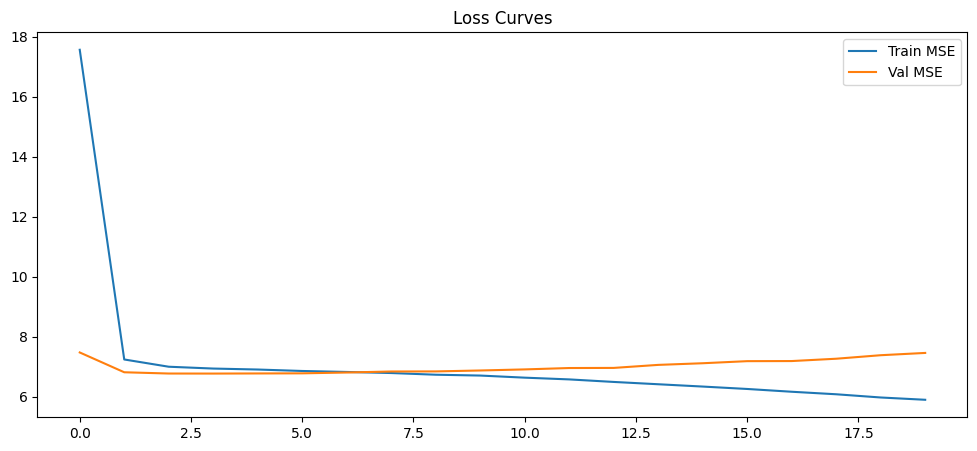

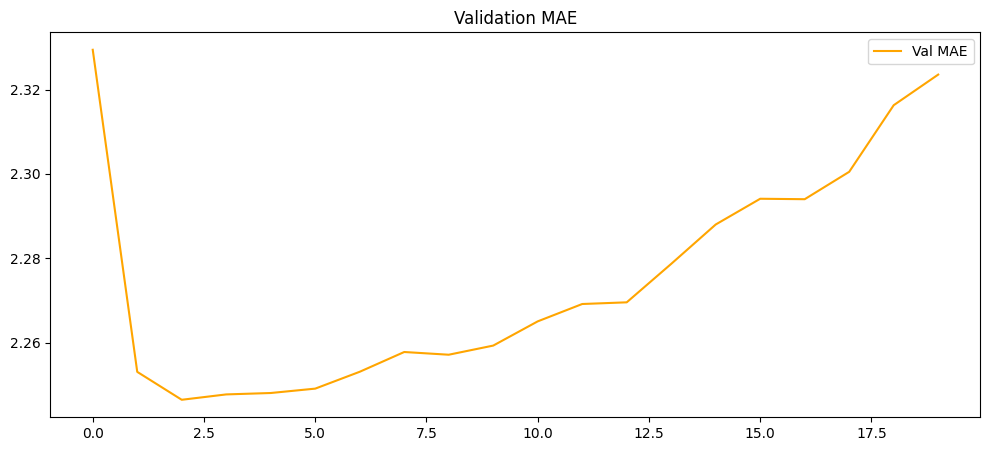

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.legend()
plt.title("Loss Curves")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(val_mae, label="Val MAE", color='orange')
plt.legend()
plt.title("Validation MAE")
plt.show()

## 🧪 Evaluate on Test Set

We compute final metrics:
- MSE
- MAE
- Pearson r (correlation)

In [10]:
from scipy.stats import pearsonr

model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).cpu().numpy()

        test_preds.append(preds)
        test_targets.append(yb.numpy())

test_preds = np.vstack(test_preds).flatten()
test_targets = np.vstack(test_targets).flatten()

mse = np.mean((test_preds - test_targets)**2)
mae = np.mean(np.abs(test_preds - test_targets))
corr, _ = pearsonr(test_preds, test_targets)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test Pearson r: {corr:.4f}")

Test MSE: 7.5233
Test MAE: 2.3386
Test Pearson r: -0.0067


## 💾 Save Model

We save:

- `attractiveness_regressor.pt`
- normalization parameters (if needed later)

In [11]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/attractiveness_regressor.pt")

print("Model saved.")

Model saved.
